# Comparison of the Income and Illegal Desposed Waste and Littering in Zürich

*Author: Tim Berger*

*Date: May 2026*



#### Introduction
The Zürich wie neu website allows the residents of Zürich to report damage and defects of the infrastructure of the city. 
Reports are sorted in different categories, such as waste or graphity. 
Illegal disposed waste and littering in the "Abfall/ Sammelstelle" category is reported most frequently (see category frequency analysis).
As the trashbags to officially despose trash are expensive, and desposing special waste is only free up to 20 kg, this analysis aims to compare the number of reports in Züri wie neu in the "Abfall/ Sammelstelle" category per neighbourhood with the mean taxable income per neighbourhood.

#### Research Question: 
Is proper special waste deposition in Zürich too expensive, does the the number of reports in Züri wie neu in the "Abfall/ Sammelstelle" category per neighbourhood correlate with the mean taxable income per neighbourhood?

#### Requirements
To be able to run this code, use the environment sds210 located in the github repository and safe the notebook_utils.py file in the same folder as this notebook.


### **Import Required Packages and Scripts**

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy import stats

import code.notebook_utils as notebook_utils

### **Download Data from the Website of the City of Zürich**

In [52]:
# the notebook_utils file contains all the functions to load the required data from the website of the canton of zurich
# if a dataset failed to load, the corresponding url in the notebook utils file should be checked

zwn_gdf_raw = notebook_utils.import_zwn_data()
neighbourhoods_gdf_raw = notebook_utils.import_neighbourhood_data()
population_df_raw = notebook_utils.import_population_data()
income_df_raw = notebook_utils.import_income_data()


Data züri wie neu loaded sugessfull
Data züri wie neu loaded sugessfull
Data Population loaded sugessfull
Data Income loaded sugessfull


### **Clean Data**

- filter income for the newest year and create a mean for the 3 tax rates

In [53]:
# display the current year
current_year = int(dt.date.today().year)

#filter dataframe for the data of the newest year (always current year minus 3)
income_df = income_df_raw[income_df_raw["StichtagDatJahr"] == str(current_year -3)].copy()


In [54]:
## create a mean for the 3 steuer tarife

#clean the data (drop na, convert to float)
income_df.dropna(subset=["SteuerEinkommen_p50"])
income_df["SteuerEinkommen_p50"] = income_df["SteuerEinkommen_p50"].astype(float)

#group by neigbourhoods and compute the mean taxable income (of the 3 median steuertarife) per person
steuertarife_grouped_by_neighbourhoods = income_df.groupby("QuarLang", as_index=False)
income_df = steuertarife_grouped_by_neighbourhoods[["SteuerEinkommen_p50"]].mean()
income_df["SteuerEinkommen_p50"] = income_df["SteuerEinkommen_p50"]*3/4

#rename the columns
income_df = income_df.rename(columns={"SteuerEinkommen_p50": "mean_income", "QuarLang": "qname"})

- filter züri wie neu data for the waste category and required columns

In [55]:
# filter the züri wie neu data for waste
zwn_waste_gdf = zwn_gdf_raw[zwn_gdf_raw["service_name"]=="Abfall/Sammelstelle"].copy()

# filter for the required columns
zwn_waste_gdf = zwn_waste_gdf[["service_request_id", "title", "geometry"]]

- filter neighbourhood data columns

In [56]:
#filter neighbourhoods data for required columns 
neighbourhoods_gdf = neighbourhoods_gdf_raw[["qname", "qnr", "geometry"]]

- clean population data

In [57]:
# filter population for the newest year

# display the current year
current_year = int(dt.date.today().year)

# filter dataframe for the newest year
population_df = population_df_raw[population_df_raw["StichtagDatJahr"] == str(current_year-1)].copy()

# clean the population data
#drop the columns not needed
population_df= population_df.drop(columns=["StichtagDatJahr", "QuarSort", "_id"])

# convert numbers to integer
population_df["AnzBestWir"] = population_df["AnzBestWir"].astype(int)

# rename the columns
population_df = population_df.rename(columns={"AnzBestWir": "population", "QuarLang": "qname"})

## **Join and Merge Data**

In [ ]:

#join the trash points to the neighbourhoods
waste_with_neighbourhoods_df = gpd.sjoin(zwn_waste_gdf, 
                                          neighbourhoods_gdf,
                                          how="inner",
                                          predicate="within")

#count the number of waste per neighbourhood and safe it as a dataframe waste_income_df
waste_income_df = waste_with_neighbourhoods_df[["qname"]].value_counts().to_frame()

#rename the column
waste_income_df = waste_income_df.rename(columns={"count":"count_waste"})

In [59]:
# merge the income to the waste_income_df

waste_income_df = pd.merge(left=waste_income_df, 
                                        right=income_df,
                                        left_on="qname",
                                        right_on="qname")
waste_income_df = waste_income_df.sort_values(by="mean_income", ascending=True)
waste_income_df = waste_income_df.set_index("qname")

In [60]:
# merge the population to the waste_income_df

waste_income_df = pd.merge(left=waste_income_df, 
                                        right=population_df,
                                        left_index=True,
                                        right_on="qname")


In [61]:
#merge the neighbourhood geometry to the waste_income_df
waste_income_gdf = pd.merge(left=neighbourhoods_gdf, 
                                        right=waste_income_df,
                                        left_on="qname",
                                        right_on="qname")

# normalize the waste per 100 person
waste_income_gdf["waste_density"] = 100* waste_income_gdf["count_waste"]/waste_income_gdf["population"] 

#sort values my mean income
waste_income_gdf = waste_income_gdf.sort_values(by="mean_income", ascending=True)

#set the index to the neighbourhood name
waste_income_gdf = waste_income_gdf.set_index("qname")

waste_income_df.head(50)


,count_waste,mean_income,qname,population
2729,306,36.37500,Hirzenbach,12597
2673,401,36.88750,Schwamendingen-Mitte,11383
1002,1639,36.90000,Hard,12817
2617,217,37.93750,Saatlen,8852
671,348,41.32500,Friesenberg,11226
2362,785,42.35000,Affoltern,27439
2532,1089,43.66250,Seebach,29320
2107,1412,45.06250,Altstetten,36874
1087,838,45.07500,Gewerbeschule,9528
747,3161,45.58750,Sihlfeld,21478


## **Plot Data**


- create a barplot to see the distribution of the ilegal desposed trash and mean income in the neighbourhoods

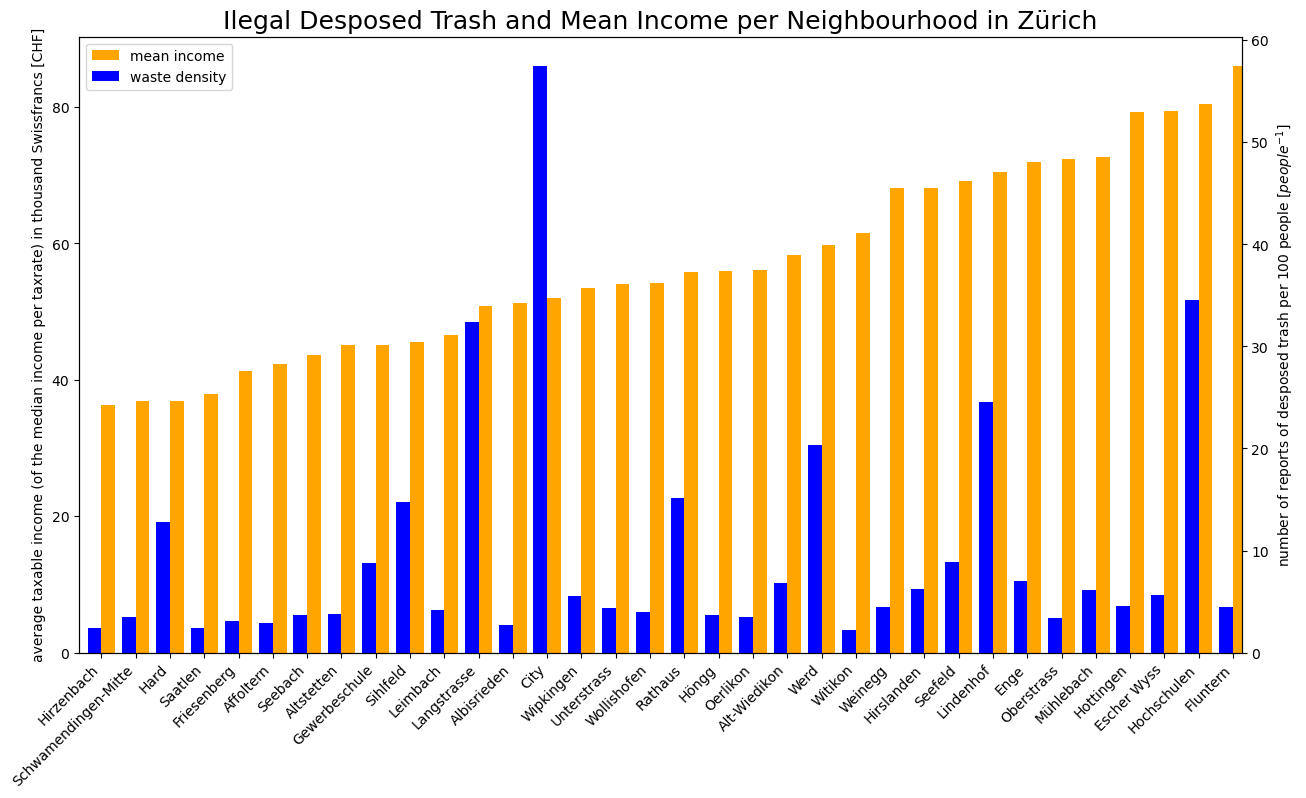

In [65]:
fig, ax1 = plt.subplots(figsize= (15,8))

#create a second y axis with the same x axis
ax2 = ax1.twinx()

#plot the income as a barplot
waste_income_gdf["mean_income"].plot(kind="bar", ax=ax1, width= 0.4, position=0, color= "orange",
                               ylabel="average taxable income (of the median income per taxrate) in thousand Swissfrancs [CHF]",
                               xlabel="", legend=False)

#set title
ax1.set_title("Ilegal Desposed Trash and Mean Income per Neighbourhood in Zürich", fontsize=18)

#plot the waste density as bars next to the income
waste_income_gdf["waste_density"].plot(kind="bar", ax=ax2, width= 0.4, position=1, color= "blue",
                         ylabel="number of reports of desposed trash per 100 people [$people^{-1}$]", legend=False)

#rotate neighbourhood labels on the x axis
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, horizontalalignment="right")

#add a legend
handles_income, labels_income = ax1.get_legend_handles_labels()
handles_waste, labels_waste = ax2.get_legend_handles_labels()
ax2.legend(handles_income + handles_waste, ["mean income", "waste density"], loc="upper left")


plt.show()

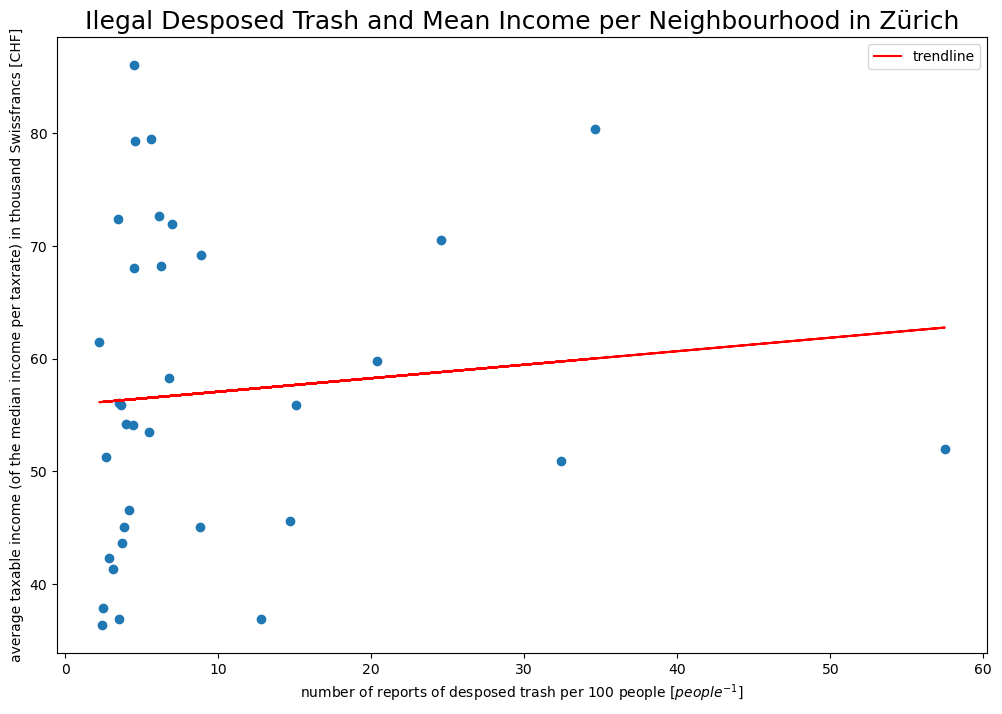

In [ ]:
fig, ax = plt.subplots(figsize= (12,8))

# create a scatter plot 

ax.scatter(x=waste_income_gdf["waste_density"], y=waste_income_gdf["mean_income"])
ax.set_title("Ilegal Desposed Trash and Mean Income per Neighbourhood in Zürich", fontsize=18)
ax.set_xlabel("number of reports of desposed trash per 100 people [$people^{-1}$]")
ax.set_ylabel("average taxable income (of the median income per taxrate) in thousand Swissfrancs [CHF]")
m, b = np.polyfit(waste_income_gdf["waste_density"], waste_income_gdf["mean_income"], 1)

ax.plot(waste_income_gdf["waste_density"], m*waste_income_gdf["waste_density"] + b, color='red', linestyle='-', label="trendline")
ax.legend()

plt.show()
